In [1]:
# Pregnancy Risk Detection Project
# Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Step 2: Load Dataset

from pathlib import Path

DATA_PATH = Path("/content/pregrisk_dataset.csv")
df = pd.read_csv(DATA_PATH)

In [4]:
df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


In [5]:
# basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     1205 non-null   int64  
 1   Systolic BP             1200 non-null   float64
 2   Diastolic               1201 non-null   float64
 3   BS                      1203 non-null   float64
 4   Body Temp               1205 non-null   int64  
 5   BMI                     1187 non-null   float64
 6   Previous Complications  1203 non-null   float64
 7   Preexisting Diabetes    1203 non-null   float64
 8   Gestational Diabetes    1205 non-null   int64  
 9   Mental Health           1205 non-null   int64  
 10  Heart Rate              1203 non-null   float64
 11  Risk Level              1187 non-null   object 
dtypes: float64(7), int64(4), object(1)
memory usage: 113.1+ KB


In [6]:
# Summary Statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1205.0,27.482988,9.196765,10.0,21.00,25.0,31.0,65.0
Systolic BP,1200.0,116.819167,18.715502,70.0,100.00,120.0,130.0,200.0
Diastolic,1201.0,77.166528,14.305148,40.0,65.00,80.0,90.0,140.0
BS,1203.0,7.501064,3.049522,3.0,6.00,6.9,7.9,19.0
Body Temp,1205.0,98.395851,1.088363,97.0,98.00,98.0,98.0,103.0
BMI,1187.0,23.315080,3.875682,0.0,20.45,23.0,25.0,37.0
Previous Complications,1203.0,0.175395,0.380463,0.0,0.00,0.0,0.0,1.0
Preexisting Diabetes,1203.0,0.288446,0.453228,0.0,0.00,0.0,1.0,1.0
Gestational Diabetes,1205.0,0.117842,0.322555,0.0,0.00,0.0,0.0,1.0
Mental Health,1205.0,0.334440,0.471990,0.0,0.00,0.0,1.0,1.0


In [7]:
# Now, Checking Missing Values

df.isnull().sum()

,0
Age,0
Systolic BP,5
Diastolic,4
BS,2
Body Temp,0
BMI,18
Previous Complications,2
Preexisting Diabetes,2
Gestational Diabetes,0
Mental Health,0


In [8]:
# Now, Checking Duplicate Records

df.duplicated().sum()

np.int64(18)

In [9]:
# Target Distribution

df["Risk Level"].value_counts()

,count
Risk Level,
Low,713
High,474


# Now, Cleaning the dataset

In [10]:
# firstly handling the Risk column which has 18 missing entries

df[df["Risk Level"].isnull()]

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
130,20,160.0,90.0,7.8,98,18.0,0.0,0.0,1,0,77.0,NaN
138,28,160.0,120.0,11.0,100,27.4,0.0,1.0,0,0,92.0,NaN
208,23,110.0,70.0,3.9,98,22.0,0.0,1.0,0,0,72.0,NaN
218,21,100.0,60.0,3.9,98,21.0,0.0,0.0,0,0,72.0,NaN
225,19,120.0,70.0,4.1,98,24.0,0.0,0.0,0,0,76.0,NaN
336,25,120.0,80.0,4.9,98,21.0,0.0,0.0,0,0,72.0,NaN
337,25,120.0,70.0,5.9,98,20.0,0.0,0.0,0,0,72.0,NaN
685,35,100.0,70.0,6.8,98,NaN,0.0,0.0,0,0,60.0,NaN
804,32,120.0,NaN,7.0,98,22.0,1.0,0.0,0,1,NaN,NaN
834,28,90.0,60.0,6.5,98,20.0,0.0,0.0,0,0,72.0,NaN


In [11]:
# Now, remove them
df = df.dropna(subset=["Risk Level"])

In [12]:
df["Risk Level"].isnull().sum()

np.int64(0)

In [13]:
df.shape

(1187, 12)

# EDA:

1. Dataset Overview
2. Target Variable Analysis
3. Numerical Feature Distribution
4. Outlier Detection
5. Feature vs Target Analysis
6. Correlation Analysis
7. Final Observations

In [14]:
# 1.Dataset Overview

# shape
print("Dataset Shape: ", df.shape)

# Data Types
display(df.dtypes)

# Statistical Summary
display(df.describe().T)

Dataset Shape:  (1187, 12)


,0
Age,int64
Systolic BP,float64
Diastolic,float64
BS,float64
Body Temp,int64
BMI,float64
Previous Complications,float64
Preexisting Diabetes,float64
Gestational Diabetes,int64
Mental Health,int64


,count,mean,std,min,25%,50%,75%,max
Age,1187.0,27.511373,9.238666,10.0,21.0,25.0,32.000,65.0
Systolic BP,1183.0,116.841082,18.694945,70.0,100.0,120.0,130.000,200.0
Diastolic,1185.0,77.208439,14.274325,40.0,65.0,80.0,90.000,140.0
BS,1186.0,7.516425,3.053211,3.0,6.0,6.9,7.975,19.0
Body Temp,1187.0,98.396799,1.089621,97.0,98.0,98.0,98.000,103.0
BMI,1173.0,23.339812,3.883635,0.0,21.0,23.0,25.000,37.0
Previous Complications,1186.0,0.177066,0.381885,0.0,0.0,0.0,0.000,1.0
Preexisting Diabetes,1186.0,0.290051,0.453977,0.0,0.0,0.0,1.000,1.0
Gestational Diabetes,1187.0,0.117944,0.322678,0.0,0.0,0.0,0.000,1.0
Mental Health,1187.0,0.335299,0.472294,0.0,0.0,0.0,1.000,1.0


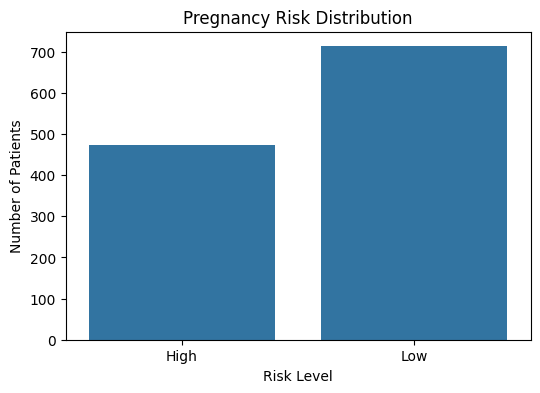

In [15]:
#  2.Target Variable Analysis

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Risk Level")

plt.title("Pregnancy Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Patients")

plt.show()

### From, looking this count plot, dataset is slightly imbalanced, not severly.

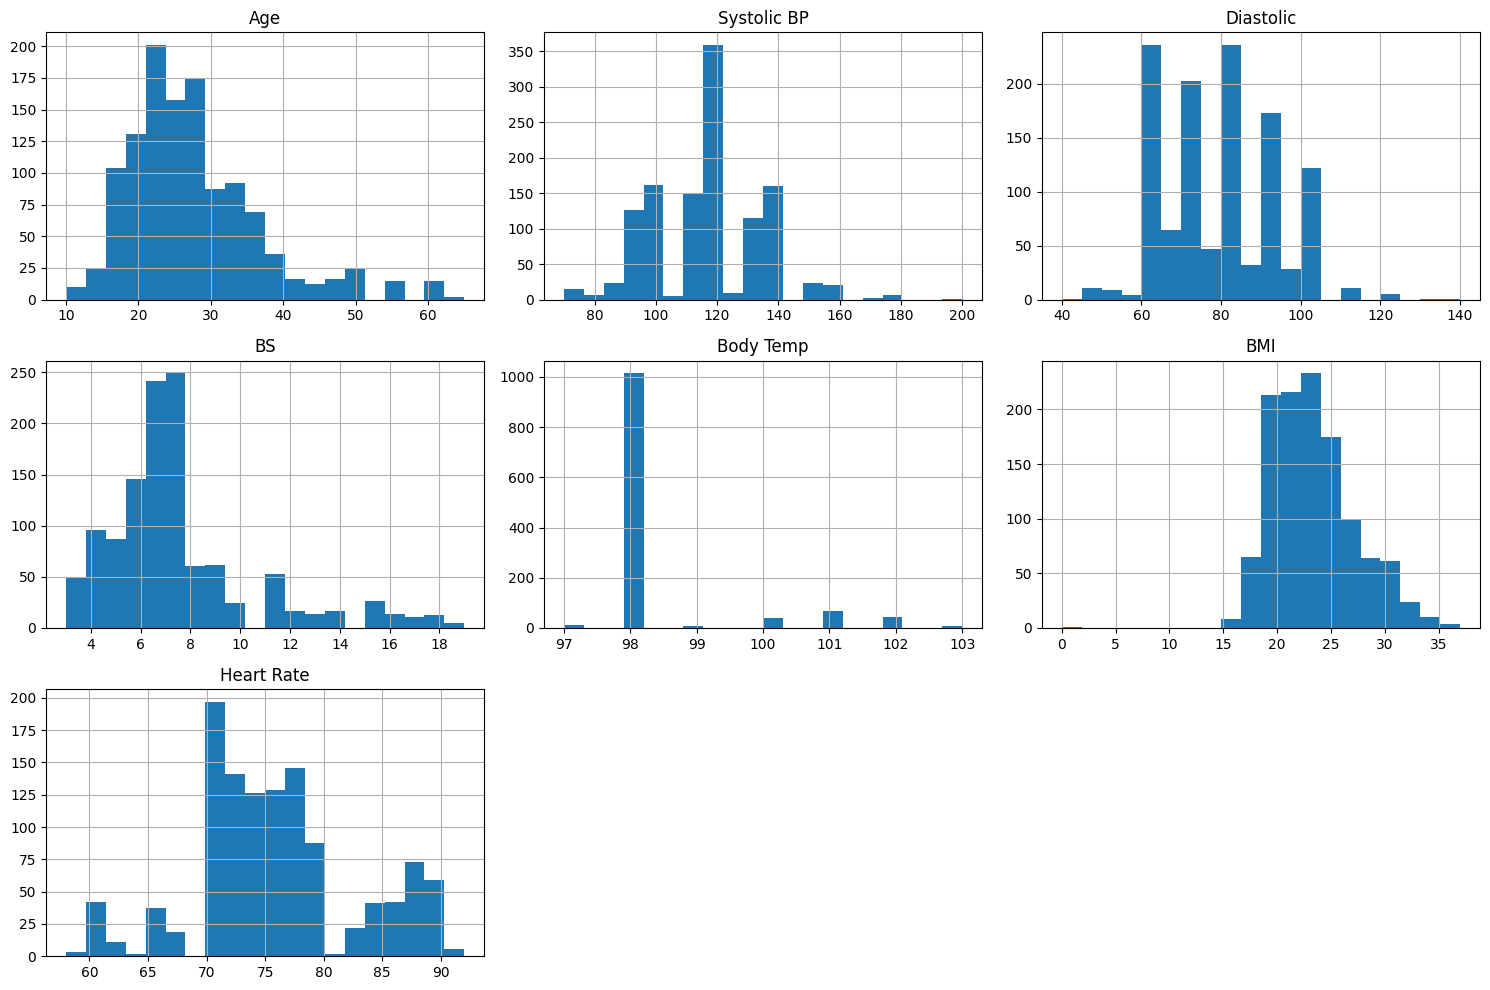

In [16]:
# 3. Numerical Feature Distribution
numerical_columns = [
    "Age",
    "Systolic BP",
    "Diastolic",
    "BS",
    "Body Temp",
    "BMI",
    "Heart Rate"
]

df[numerical_columns].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

### Most patients are young adults, between age of 20 30

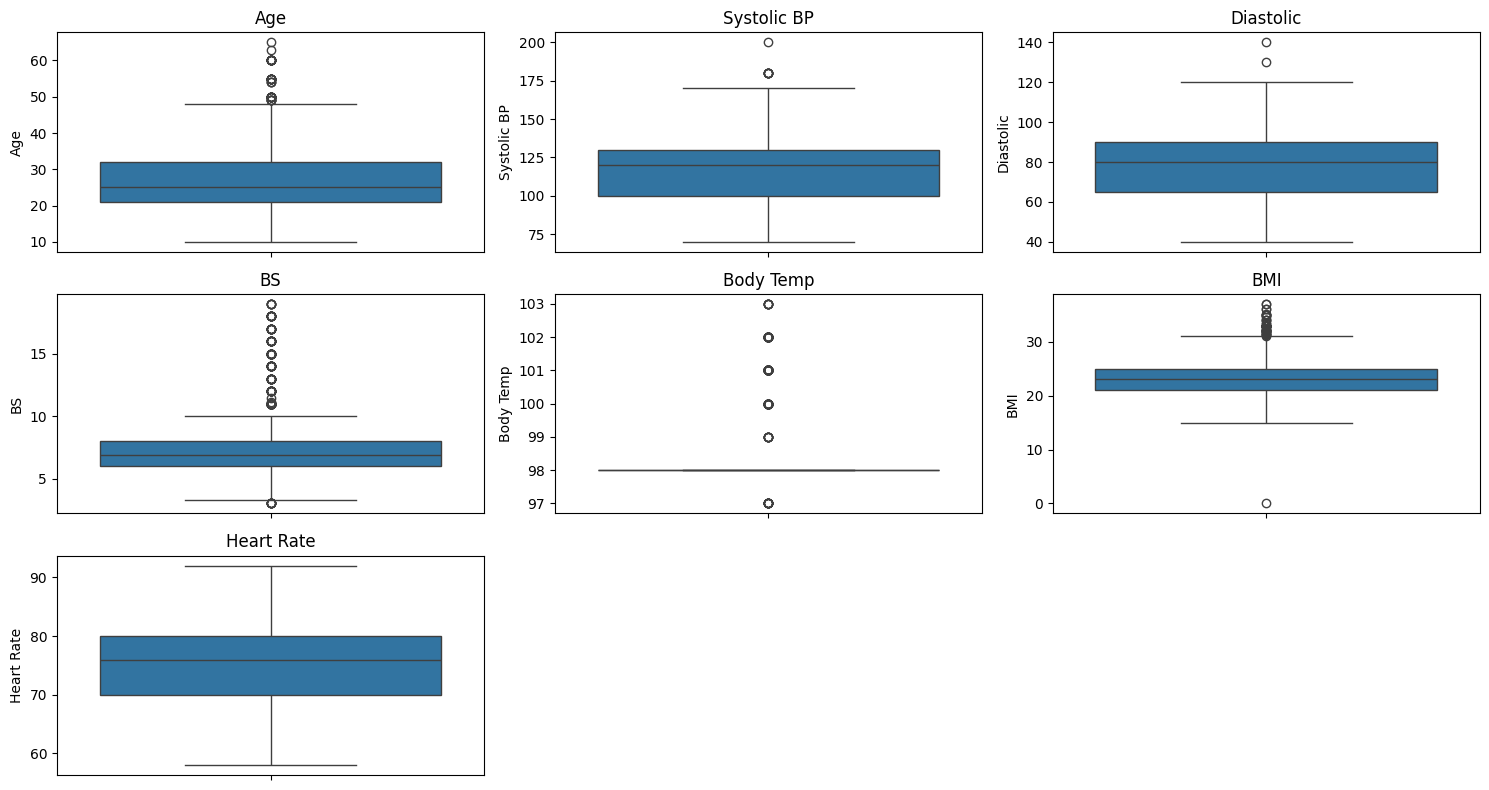

In [17]:
# 4. Boxplots (Outlier Detection)
plt.figure(figsize=(15,8))

for i, column in enumerate(numerical_columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

### from this we can see that in,
 - **Age**: In this Column there are some outliers, like womens greater than age 50
 - **Systolic BP**: In this column, there are some outliers and average approx 124 Systolic BP
 - **Heart Rate**: In this column, the data is approx normally distributed.

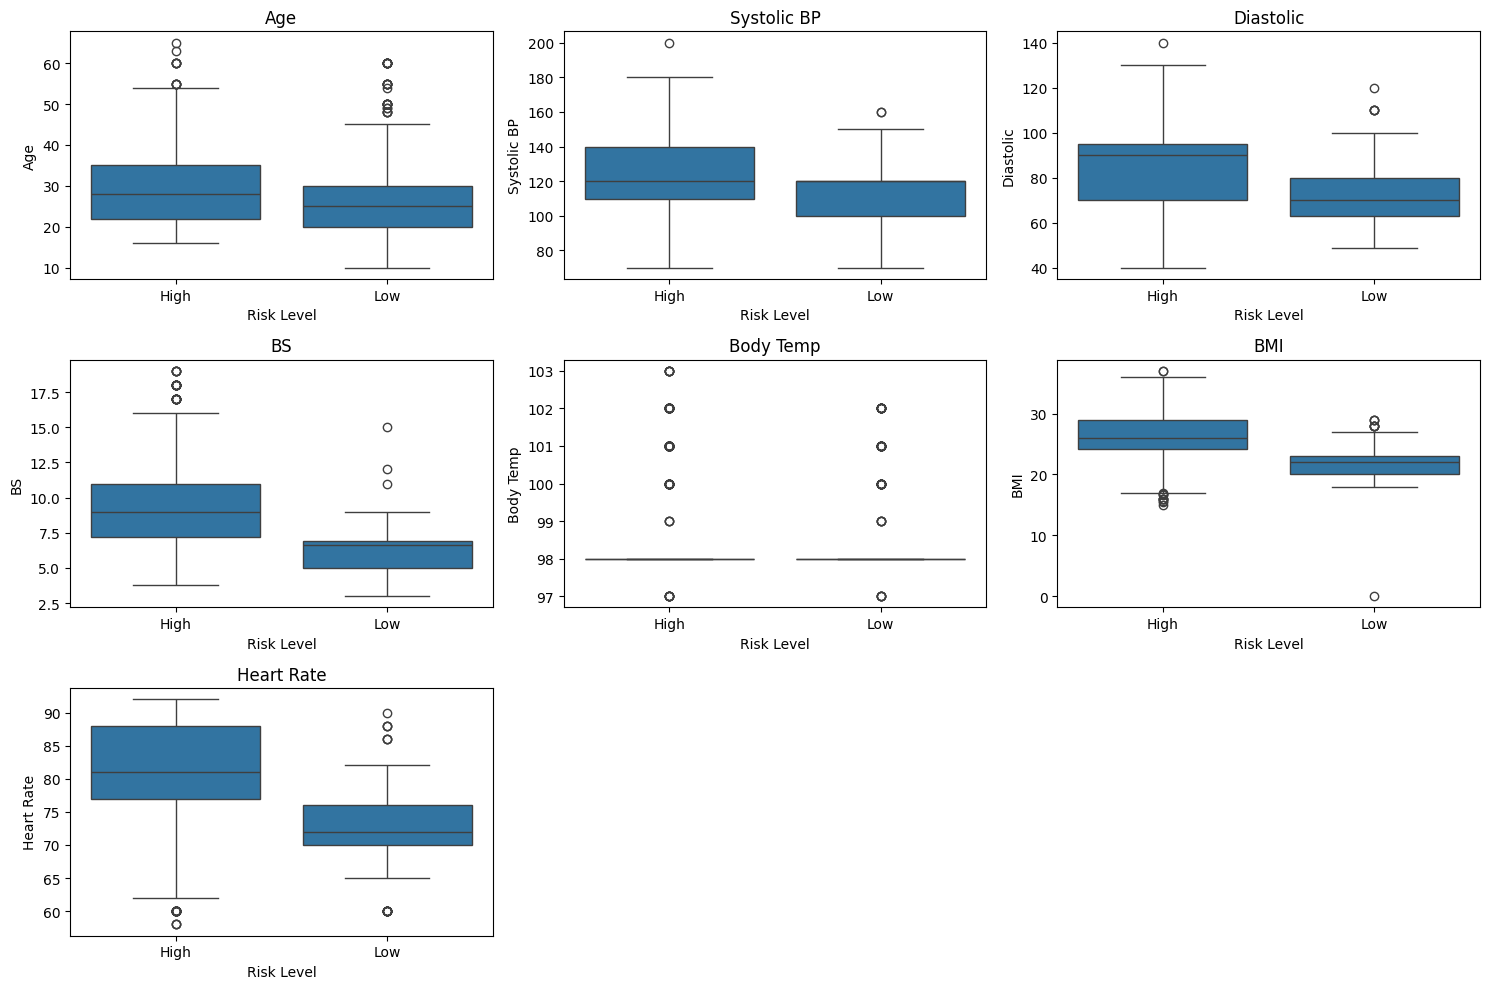

In [18]:
# 5. Feature vs Target
plt.figure(figsize=(15,10))

for i, column in enumerate(numerical_columns):
    plt.subplot(3,3,i+1)

    sns.boxplot(
        data=df,
        x="Risk Level",
        y=column
    )

    plt.title(column)

plt.tight_layout()
plt.show()

### High Risk patients have consistently higher Blood Sugar, so Blood Sugar is an important predictor



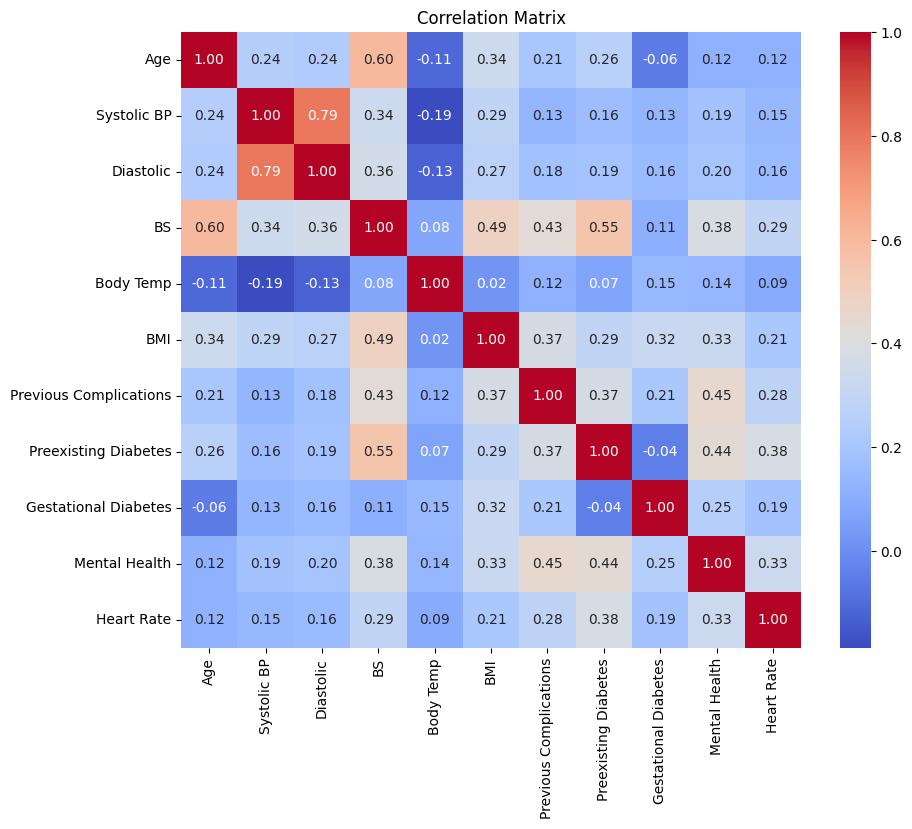

In [19]:
# 6. Correlation Matrix
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Now, Splitting the dataset for preprocessing into training and testing data

In [20]:
# Separate Features and Target
x = df.drop("Risk Level", axis=1)
y = df["Risk Level"]

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)
# stratify=y sets preserve approximately the same class distribution

# Now, verifying the train_test data
print("Training Features : ", x_train.shape)
print("Testing Features : ", x_test.shape)
print("Training Target : ", y_train.shape)
print("Testing Target : ", y_test.shape)

# Now, Checking Class Distribution
print("Training Class Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution")
print(y_test.value_counts(normalize=True))

Training Features :  (949, 11)
Testing Features :  (238, 11)
Training Target :  (949,)
Testing Target :  (238,)
Training Class Distribution
Risk Level
Low     0.600632
High    0.399368
Name: proportion, dtype: float64

Testing Class Distribution
Risk Level
Low     0.60084
High    0.39916
Name: proportion, dtype: float64


### Now, Preprocessing starts here



In [22]:
x_train.isnull().sum()

,0
Age,0
Systolic BP,3
Diastolic,1
BS,1
Body Temp,0
BMI,13
Previous Complications,1
Preexisting Diabetes,1
Gestational Diabetes,0
Mental Health,0


In [23]:
x_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,949.0,27.326660,9.087986,10.0,21.0,25.0,31.0,65.0
Systolic BP,946.0,116.843552,18.783220,70.0,100.0,120.0,130.0,200.0
Diastolic,948.0,77.107595,14.527875,40.0,65.0,80.0,90.0,140.0
BS,948.0,7.496508,3.044421,3.0,6.0,6.9,7.9,19.0
Body Temp,949.0,98.423604,1.122136,97.0,98.0,98.0,98.0,103.0
BMI,936.0,23.326603,3.875386,0.0,21.0,23.0,25.0,37.0
Previous Complications,948.0,0.171941,0.377528,0.0,0.0,0.0,0.0,1.0
Preexisting Diabetes,948.0,0.291139,0.454527,0.0,0.0,0.0,1.0,1.0
Gestational Diabetes,949.0,0.119073,0.324045,0.0,0.0,0.0,0.0,1.0
Mental Health,949.0,0.332982,0.471529,0.0,0.0,0.0,1.0,1.0


### So, looking from the above information, we can say that :
| Feature                | Strategy | Reason                                |
| ---------------------- | -------- | ------------------------------------- |
| Systolic BP            | Median   | Robust to outliers                    |
| Diastolic              | Median   | Robust to outliers                    |
| BS                     | Median   | Medical values can be extreme         |
| BMI                    | Median   | Handles skew/outliers well            |
| Heart Rate             | Median   | Consistent and robust                 |
| Previous Complications | Median   | Returns a valid binary value (0 or 1) |
| Preexisting Diabetes   | Median   | Returns a valid binary value (0 or 1) |


In [24]:
from sklearn.impute import SimpleImputer

# Creating the imputer
imputer = SimpleImputer(strategy="median")

# Learning medians from the training data and fill missing values
x_train = imputer.fit_transform(x_train)

# Applying the same learned medians to the test data
x_test = imputer.transform(x_test)

### Now, Feature Scaling (StandardScaler)

One of the most common scaling methods is Standardization, implemented by StandardScaler.

The formula is:

z=(x−μ)/σ

**Scaling** causes the mean to 0 and std to 1 approx

In [25]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Learn mean and std from training data
x_train = scaler.fit_transform(x_train)

# Apply the same scaling to test data
x_test = scaler.transform(x_test)

In [26]:
import pandas as pd

x_train_scaled = pd.DataFrame(x_train, columns=x.columns)

x_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,949.0,7.487279e-18,1.000527,-1.907551,-0.696523,-0.256150,0.404411,4.147586
Systolic BP,949.0,2.620547e-17,1.000527,-2.499597,-0.899122,0.167862,0.701353,4.435796
Diastolic,949.0,2.873243e-16,1.000527,-2.557086,-0.834477,0.199089,0.888133,4.333353
BS,949.0,-4.679549e-17,1.000527,-1.478289,-0.491860,-0.195931,0.132879,3.782666
Body Temp,949.0,-2.934077e-15,1.000527,-1.269324,-0.377697,-0.377697,-0.377697,4.080441
BMI,949.0,-5.446995e-16,1.000527,-6.062606,-0.603639,-0.083738,0.436164,3.555574
Previous Complications,949.0,7.487279e-18,1.000527,-0.455389,-0.455389,-0.455389,-0.455389,2.195925
Preexisting Diabetes,949.0,8.984734e-17,1.000527,-0.640394,-0.640394,-0.640394,1.561540,1.561540
Gestational Diabetes,949.0,7.206506e-17,1.000527,-0.367651,-0.367651,-0.367651,-0.367651,2.719969
Mental Health,949.0,-2.246184e-17,1.000527,-0.706548,-0.706548,-0.706548,1.415332,1.415332


# Now, we will apply the SMOTE(Synthetic Minority Over-sampling Technique) -
SMOTE (Synthetic Minority Over-sampling Technique) is an oversampling method used in machine learning to address class imbalance by generating synthetic examples of the minority class.

In [27]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
x_train, y_train = smote.fit_resample(x_train, y_train)

# Now, verifying
print("Training Features : ", x_train.shape)
print("Training Target : ", y_train.shape)
print(y_train.value_counts())

Training Features :  (1140, 11)
Training Target :  (1140,)
Risk Level
Low     570
High    570
Name: count, dtype: int64


Beacuse, before SMOTE:
<br>
**Training**

Low ≈ 570

High ≈ 379

SMOTE creates approximately 191 new High Risk samples.<br>
After SMOTE:


Low  = 570

High = 570

# Now, Applying the models for predictions

In [28]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

# creating model
lr = LogisticRegression(random_state = 42)

# training
lr.fit(x_train, y_train)

# predicting
y_pred_lr = lr.predict(x_test)

# Verifying
print(y_pred_lr.shape)
print(y_pred_lr[:10])


(238,)
['Low' 'High' 'Low' 'Low' 'High' 'Low' 'High' 'High' 'High' 'Low']


# Now, Model Evaluation:

**Accuracy** - It measures how many predictions are correct overall.<br>

**Precision** - It measures out of all the Corrected positive predictions, how many are actually correct.<br>

**Recall** - It measures out of all actual positive, how many model predicted correctly(positive), It is one of the very important measure in the Health_Care Systyms. **for example**: Mistake

Thinking Recall and Precision are the same.

No.

Precision asks:

"When I predict High Risk, how often am I correct?"

Recall asks:

"Out of all High Risk patients, how many did I find?"<br>

**F1-Score** - It combines Precision and Recall into a single number.
It is the harmonic mean, not the arithmetic mean.





In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["High", "Low"]
)

print(cm)

[[ 91   4]
 [  2 141]]


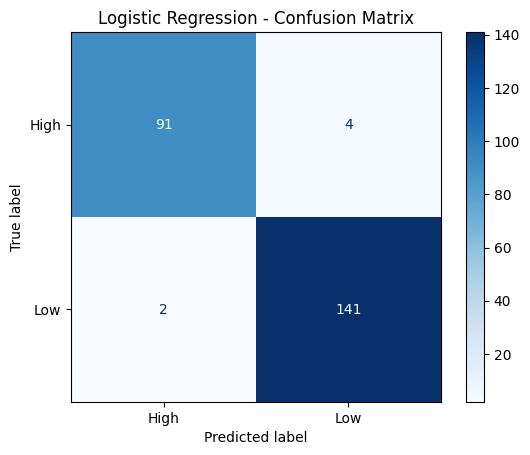

In [30]:
# visualizing the Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    labels = ["High", "Low"],
    cmap = "Blues"
)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [31]:
# Now, Calculating the Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy)

Accuracy: 0.9747899159663865


In [32]:
# Now, calculating the precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred_lr, pos_label="High")
print("Precision:", precision)

Precision: 0.978494623655914


In [33]:
# Now, Calculating the Recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred_lr, pos_label = "High")
print("Recall:", recall)

Recall: 0.9578947368421052


In [34]:
# Now, calculating the F1 Score
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred_lr,
    pos_label="High"
)

print("F1 Score:", f1)

F1 Score: 0.9680851063829787


### Now, Classification Report :-
It is simply a summary report of a particular model.

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

        High       0.98      0.96      0.97        95
         Low       0.97      0.99      0.98       143

    accuracy                           0.97       238
   macro avg       0.98      0.97      0.97       238
weighted avg       0.97      0.97      0.97       238



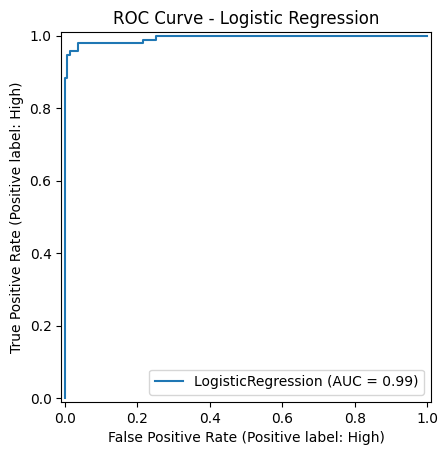

ROC AUC: 0.9937430990062569


In [36]:
# Now, ROC and ROC-AUC Curve for Logistic Regression

# ROC curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    lr,
    x_test,
    y_test,
    pos_label="High"
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

# ROC-AUC Curve
from sklearn.metrics import roc_auc_score

y_test_binary = (y_test == "High").astype(int)

y_prob_lr = lr.predict_proba(x_test)[:, 0]

roc_auc = roc_auc_score(
    y_test_binary,
    y_prob_lr
)

print("ROC AUC:", roc_auc)

### Now, building the another model - **Decision Tree**

In [37]:
from sklearn.tree import DecisionTreeClassifier

# creating the model
dt = DecisionTreeClassifier(
    criterion = "gini",
    random_state = 42
)

# now, training the model
dt.fit(x_train, y_train)

# predicting
y_pred_dt = dt.predict(x_test)

In [38]:
# Now, Model Evaluation:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, pos_label="High"))
print("Recall   :", recall_score(y_test, y_pred_dt, pos_label="High"))
print("F1 Score :", f1_score(y_test, y_pred_dt, pos_label="High"))

Accuracy : 0.9621848739495799
Precision: 0.967391304347826
Recall   : 0.9368421052631579
F1 Score : 0.9518716577540107


[[ 89   6]
 [  3 140]]


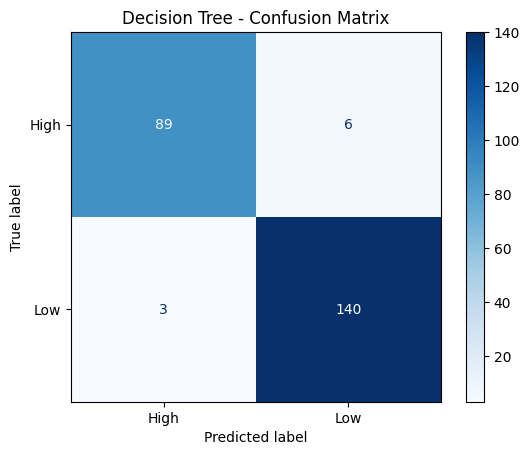

In [39]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred_dt,
    labels=["High", "Low"]
)

print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    labels = ["High", "Low"],
    cmap = "Blues"
)
plt.title("Decision Tree - Confusion Matrix")
plt.show()


In [40]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

        High       0.97      0.94      0.95        95
         Low       0.96      0.98      0.97       143

    accuracy                           0.96       238
   macro avg       0.96      0.96      0.96       238
weighted avg       0.96      0.96      0.96       238



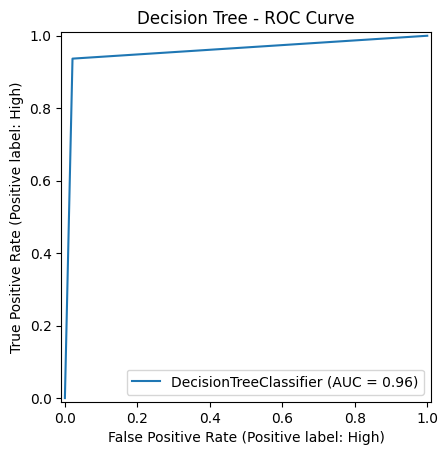

ROC AUC: 0.9579315421420685


In [41]:
# Now, ROC Curve and ROC-AUC Curve

# ROC Curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    dt,
    x_test,
    y_test,
    pos_label="High"
)

plt.title("Decision Tree - ROC Curve")
plt.show()

# ROC-AUC Curve
import numpy as np
from sklearn.metrics import roc_auc_score

high_index = np.where(dt.classes_ == "High")[0][0]

y_prob_dt = dt.predict_proba(x_test)[:, high_index]

y_test_binary = (y_test == "High").astype(int)

roc_auc = roc_auc_score(y_test_binary, y_prob_dt)

print("ROC AUC:", roc_auc)

### Now, building the another model - **RadomForest**

In [42]:
from sklearn.ensemble import RandomForestClassifier

# creating the model
rf = RandomForestClassifier(
    random_state = 42
)

# Now, training the model
rf.fit(x_train, y_train)

# predicting
y_pred_rf = rf.predict(x_test)

In [43]:
# Now, Model Evaluation:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="High"))
print("Recall   :", recall_score(y_test, y_pred_rf, pos_label="High"))
print("F1 Score :", f1_score(y_test, y_pred_rf, pos_label="High"))

Accuracy : 0.9957983193277311
Precision: 1.0
Recall   : 0.9894736842105263
F1 Score : 0.9947089947089947


[[ 94   1]
 [  0 143]]


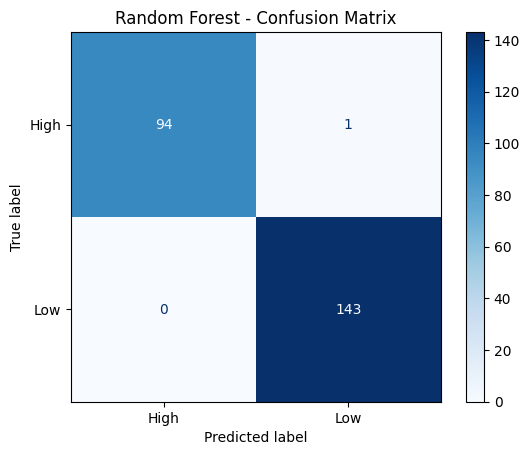

In [44]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["High", "Low"]
)

print(cm)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    labels = ["High", "Low"],
    cmap = "Blues"
)
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [45]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        High       1.00      0.99      0.99        95
         Low       0.99      1.00      1.00       143

    accuracy                           1.00       238
   macro avg       1.00      0.99      1.00       238
weighted avg       1.00      1.00      1.00       238



ROC AUC: 1.0


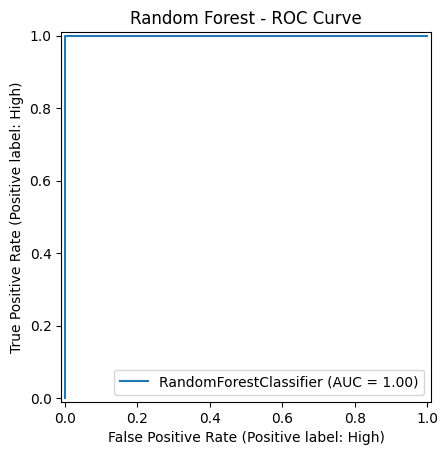

In [46]:
# Now, ROC Curve and ROC-AUC Curve

# ROC Curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    rf,
    x_test,
    y_test,
    pos_label="High"
)

plt.title("Random Forest - ROC Curve")
plt.show

# ROC-AUC Curve
import numpy as np
from sklearn.metrics import roc_auc_score

high_index = np.where(rf.classes_ == "High")[0][0]

y_prob_rf = rf.predict_proba(x_test)[:, high_index]

y_test_binary = (y_test == "High").astype(int)

roc_auc = roc_auc_score(
    y_test_binary,
    y_prob_rf
)

print("ROC AUC:", roc_auc)

# Now, Finding important features

                   Feature  Importance
7     Preexisting Diabetes    0.223632
3                       BS    0.213698
5                      BMI    0.149055
10              Heart Rate    0.132830
8     Gestational Diabetes    0.089276
9            Mental Health    0.089119
6   Previous Complications    0.036210
0                      Age    0.021560
2                Diastolic    0.019857
1              Systolic BP    0.018414
4                Body Temp    0.006349


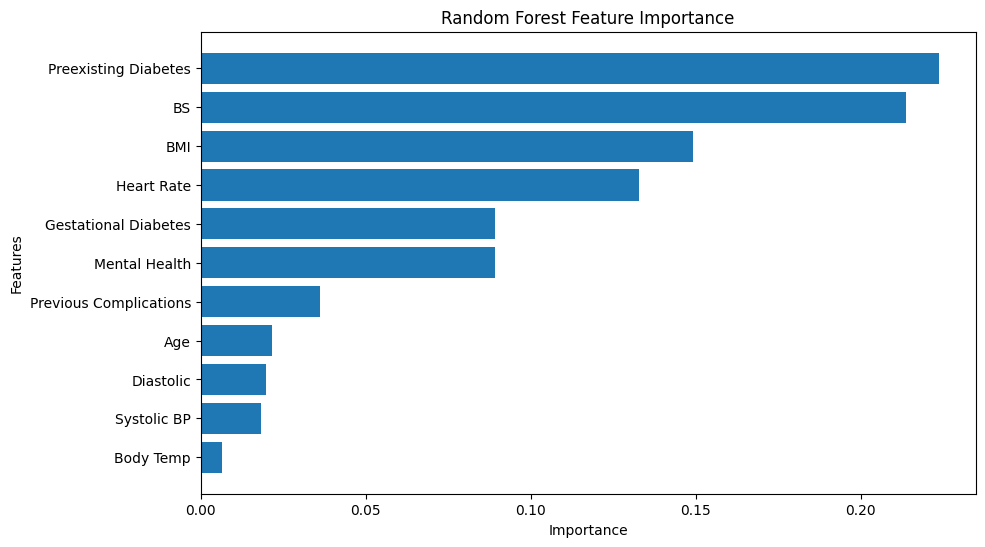

In [47]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [48]:
# Now, finding the training Accuracy
from sklearn.metrics import accuracy_score

train_pred_rf = rf.predict(x_train)

train_accuracy = accuracy_score(y_train, train_pred_rf)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 1.0


### Now, building the another model - XGBoost

In [49]:
!pip install xgboost

In [50]:
from xgboost import XGBClassifier

# Encodinng the target variable into numerical value cause, xgboost takes numerical value

from sklearn.preprocessing import LabelEncoder

lable_encoder = LabelEncoder()

y_train_encoded = lable_encoder.fit_transform(y_train)
y_test_encoded = lable_encoder.transform(y_test)

# Now, creating the model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# training model
xgb.fit(
    x_train,
    y_train_encoded
)

# predicting
y_pred_encoded = xgb.predict(x_test)

y_pred_xgb = lable_encoder.inverse_transform(y_pred_encoded)

In [51]:
# Now, Model Evaluation:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb, pos_label="High"))
print("Recall   :", recall_score(y_test, y_pred_xgb, pos_label="High"))
print("F1 Score :", f1_score(y_test, y_pred_xgb, pos_label="High"))


Accuracy : 0.9957983193277311
Precision: 1.0
Recall   : 0.9894736842105263
F1 Score : 0.9947089947089947


[[ 94   1]
 [  0 143]]


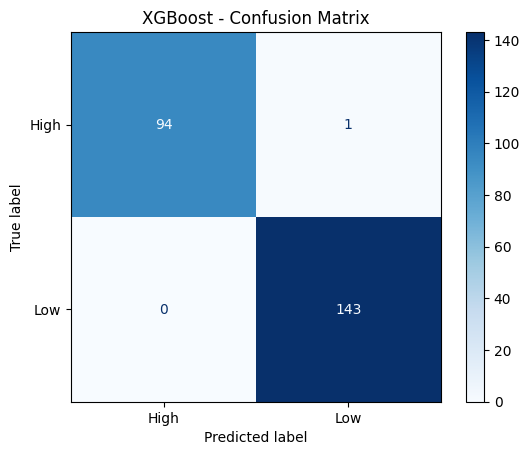

In [52]:
# Confusion Matrix:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_xgb,
    labels=["High", "Low"]
)

print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    labels = ["High", "Low"],
    cmap = "Blues"
)
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [53]:
# Now, Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

        High       1.00      0.99      0.99        95
         Low       0.99      1.00      1.00       143

    accuracy                           1.00       238
   macro avg       1.00      0.99      1.00       238
weighted avg       1.00      1.00      1.00       238



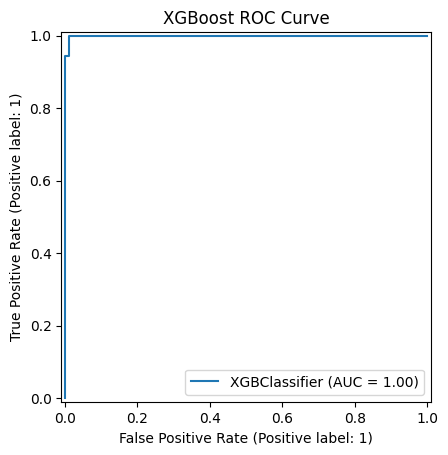

ROC AUC: 0.9994111152005889


In [54]:
# Now, ROC Curve and ROC-AUC Curve

# ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    xgb,
    x_test,
    y_test_encoded
)

plt.title("XGBoost ROC Curve")
plt.show()

# ROC-AUC Curve
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(
    y_test_encoded,
    y_prob_xgb
)

print("ROC AUC:", roc_auc)

### Now, Building GridSearchCV to fine tune the Hyperparameters

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}   # total = 2 * 3 * 2 * 2 = 24 Combinations

# Now, creating the basemodel
rf = RandomForestClassifier(
    random_state=42
)

# Now, creating the GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,   # the model to tune (here, the randomforest.)
    param_grid=param_grid,    # Hyperparameter combinations to try
    cv=5,   # 5 - folds CV
    scoring="accuracy",   # Choose the model with the highest average accuracy.
    n_jobs=-1,    # use all CPU cores.
    verbose=2   # Print training progress.
)

# Now, training the model
grid_search.fit(
    x_train,
    y_train
)

# base parameters
print(grid_search.best_params_)

# Best Cross-Validation Score
print(grid_search.best_score_)

# Best Model
best_rf = grid_search.best_estimator_

# Now, predicting
y_pred_best = best_rf.predict(x_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.9850877192982456


In [56]:
# Now, Computing the Metrics(Classification Report)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, pos_label="High"))
print("Recall   :", recall_score(y_test, y_pred_best, pos_label="High"))
print("F1 Score :", f1_score(y_test, y_pred_best, pos_label="High"))

print(classification_report(y_test, y_pred_best))

Accuracy : 0.9957983193277311
Precision: 1.0
Recall   : 0.9894736842105263
F1 Score : 0.9947089947089947
              precision    recall  f1-score   support

        High       1.00      0.99      0.99        95
         Low       0.99      1.00      1.00       143

    accuracy                           1.00       238
   macro avg       1.00      0.99      1.00       238
weighted avg       1.00      1.00      1.00       238



### Now, Saving the Final Model

In [57]:
import pickle

with open("pregnancy_risk_detector.pkl", "wb") as file:
    pickle.dump(best_rf, file)

print("Model saved successfully!")

Model saved successfully!


In [58]:
# Saving the Scaler model

import pickle

with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

# Now, also saving the SimpleImputer
with open("imputer.pkl", "wb") as file:
    pickle.dump(imputer, file)

print("Imputer saved successfully!")

Scaler saved successfully!
Imputer saved successfully!
